We aim to investigate in the ellipse defined by $\mathcal{E}(X/s^2)$ with $\mathcal{E}(P):=\{x\in\mathbb{R}^n \mid x^T P x \leq 1\}$, i.e. $\{x \mid x^T X x \leq s^2\}$.

For different values of $s$ and $X$

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

In [21]:
s1, X1 = 1.0, np.eye(2)

In [22]:
def plot_ellipse(
    ax: plt.Axes,
    s: float,
    X: NDArray,
    n_points: int = 400,
    fill: bool = False,
    **kwargs,
) -> plt.Line2D:
    """Plot the ellipse E(X/s^2) = {x in R^2 | x^T X x <= s^2} on `ax`.

    With X = V diag(w) V^T (X symmetric positive definite), the boundary is
    x(t) = s V diag(1/sqrt(w)) [cos t, sin t]^T, i.e. the principal axes point
    along the eigenvectors of X and have semi-axis lengths s / sqrt(w). Large
    eigenvalues of X are the tight directions.
    """
    X = np.asarray(X, dtype=np.float64)
    if X.shape != (2, 2):
        raise ValueError(f"only the two dimensional case is supported, got {X.shape}")
    X = 0.5 * (X + X.T)  # symmetrize, the certificate matrix is symmetric by construction
    w, V = np.linalg.eigh(X)
    if np.any(w <= 0.0):
        raise ValueError(f"X must be positive definite, eigenvalues are {w}")
    if s <= 0.0:
        raise ValueError(f"s must be positive, got {s}")

    t = np.linspace(0.0, 2.0 * np.pi, n_points)
    unit_circle = np.stack([np.cos(t), np.sin(t)])  # (2, n_points)
    points = s * V @ (unit_circle / np.sqrt(w)[:, None])  # (2, n_points)

    (line,) = ax.plot(points[0], points[1], **kwargs)
    if fill:
        ax.fill(points[0], points[1], color=line.get_color(), alpha=0.15)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(True, alpha=0.3)
    return line

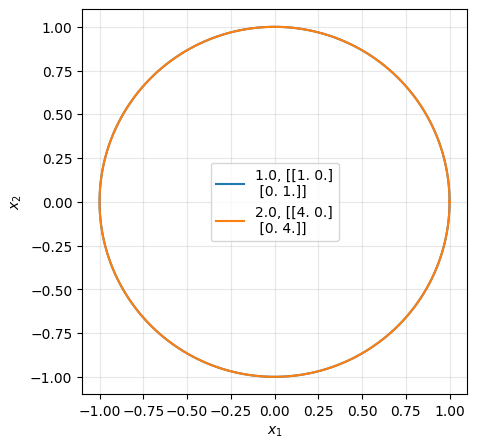

In [37]:
fig, ax = plt.subplots(figsize=(10,5))

c = 2
s1, X1 = 1.0, np.eye(2)
s2, X2 = 1.0*c, np.eye(2)*c**2

plot_ellipse(ax, s1, X1, label=f'{s1}, {X1}')
plot_ellipse(ax, s2, X2, label=f'{s2}, {X2}')

ax.legend()

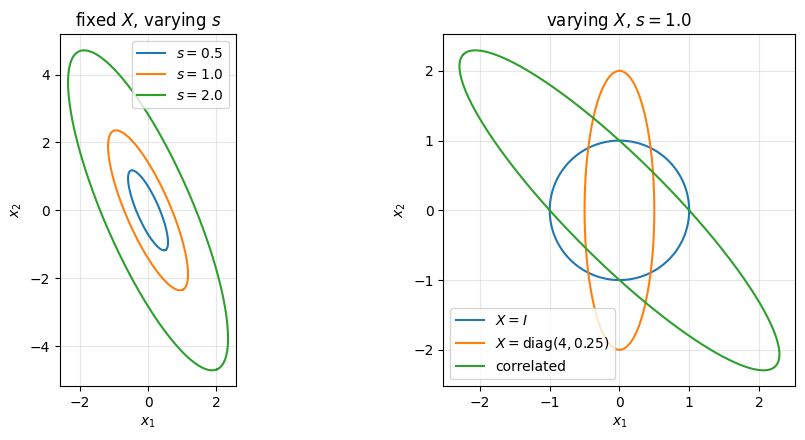

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

# varying s for a fixed X
X = np.array([[2.0, 0.8], [0.8, 0.5]])
for s in [0.5, 1.0, 2.0]:
    plot_ellipse(axs[0], s, X, label=f"$s={s}$")
axs[0].set_title(r"fixed $X$, varying $s$")
axs[0].legend()

# varying X for a fixed s
for name, X_i in {
    "$X=I$": np.eye(2),
    r"$X=\mathrm{diag}(4, 0.25)$": np.diag([4.0, 0.25]),
    "correlated": np.array([[1.0, 0.9], [0.9, 1.0]]),
}.items():
    plot_ellipse(axs[1], s1, X_i, label=name)
axs[1].set_title(rf"varying $X$, $s={s1}$")
axs[1].legend()

fig.tight_layout()
plt.show()

In [ ]:
# sanity check: the boundary points satisfy x^T X x = s^2
_fig, _ax = plt.subplots()
_s, _X = 1.7, np.array([[2.0, 0.8], [0.8, 0.5]])
_line = plot_ellipse(_ax, _s, _X)
_pts = np.stack([_line.get_xdata(), _line.get_ydata()])
_vals = np.einsum("in,ij,jn->n", _pts, _X, _pts)
print(f"max |x^T X x - s^2| = {np.max(np.abs(_vals - _s**2)):.2e}")
plt.close(_fig)